In [1]:
import pandas as pd
import xgboost as xgb
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Data
# Ganti nama file di bawah ini jika nama datasetmu berbeda
df = pd.read_excel("penelitian_bersih.xlsx")

In [2]:
fitur = [
    "baduta",
    "balita",
    "pus",
    "pus_hamil",
    "terlalu_muda",
    "terlalu_tua",
    "jarak_dekat",
    "banyak_anak",
    "tanpa_kb",
    "jamban_layak_tidak",
    "sumber_air_layak_tidak"
]

# Filter 'fitur' to include only columns present in df
fitur = [col for col in fitur if col in df.columns]

X = df[fitur]
y = df["risiko_stunting"]

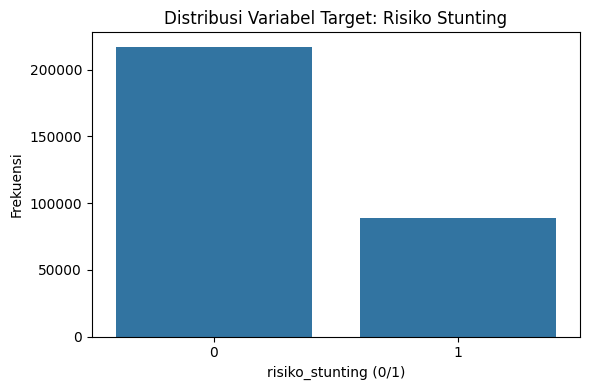

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df.copy()

plt.figure(figsize=(6,4))
sns.countplot(x='risiko_stunting', data=df_eda)
plt.title('Distribusi Variabel Target: Risiko Stunting')
plt.xlabel('risiko_stunting (0/1)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

Proporsi Risiko Stunting (%):


,count,percent
risiko_stunting,,
0,216989,70.98
1,88723,29.02


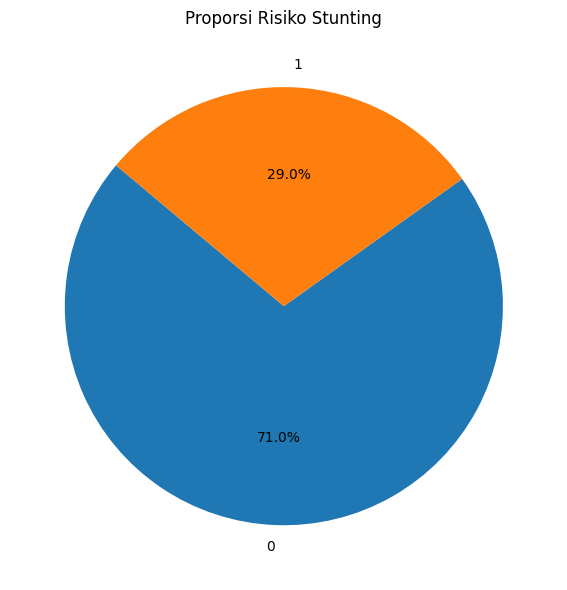

In [4]:
y_counts = df_eda["risiko_stunting"].value_counts(dropna=False)
y_pct = (y_counts / y_counts.sum()) * 100
print("Proporsi Risiko Stunting (%):")
display(pd.DataFrame({'count': y_counts, 'percent': y_pct.round(2)}))

plt.figure(figsize=(6,6))
plt.pie(y_pct.values, labels=y_pct.index, autopct='%1.1f%%', startangle=140)
plt.title('Proporsi Risiko Stunting')
plt.tight_layout()
plt.show()

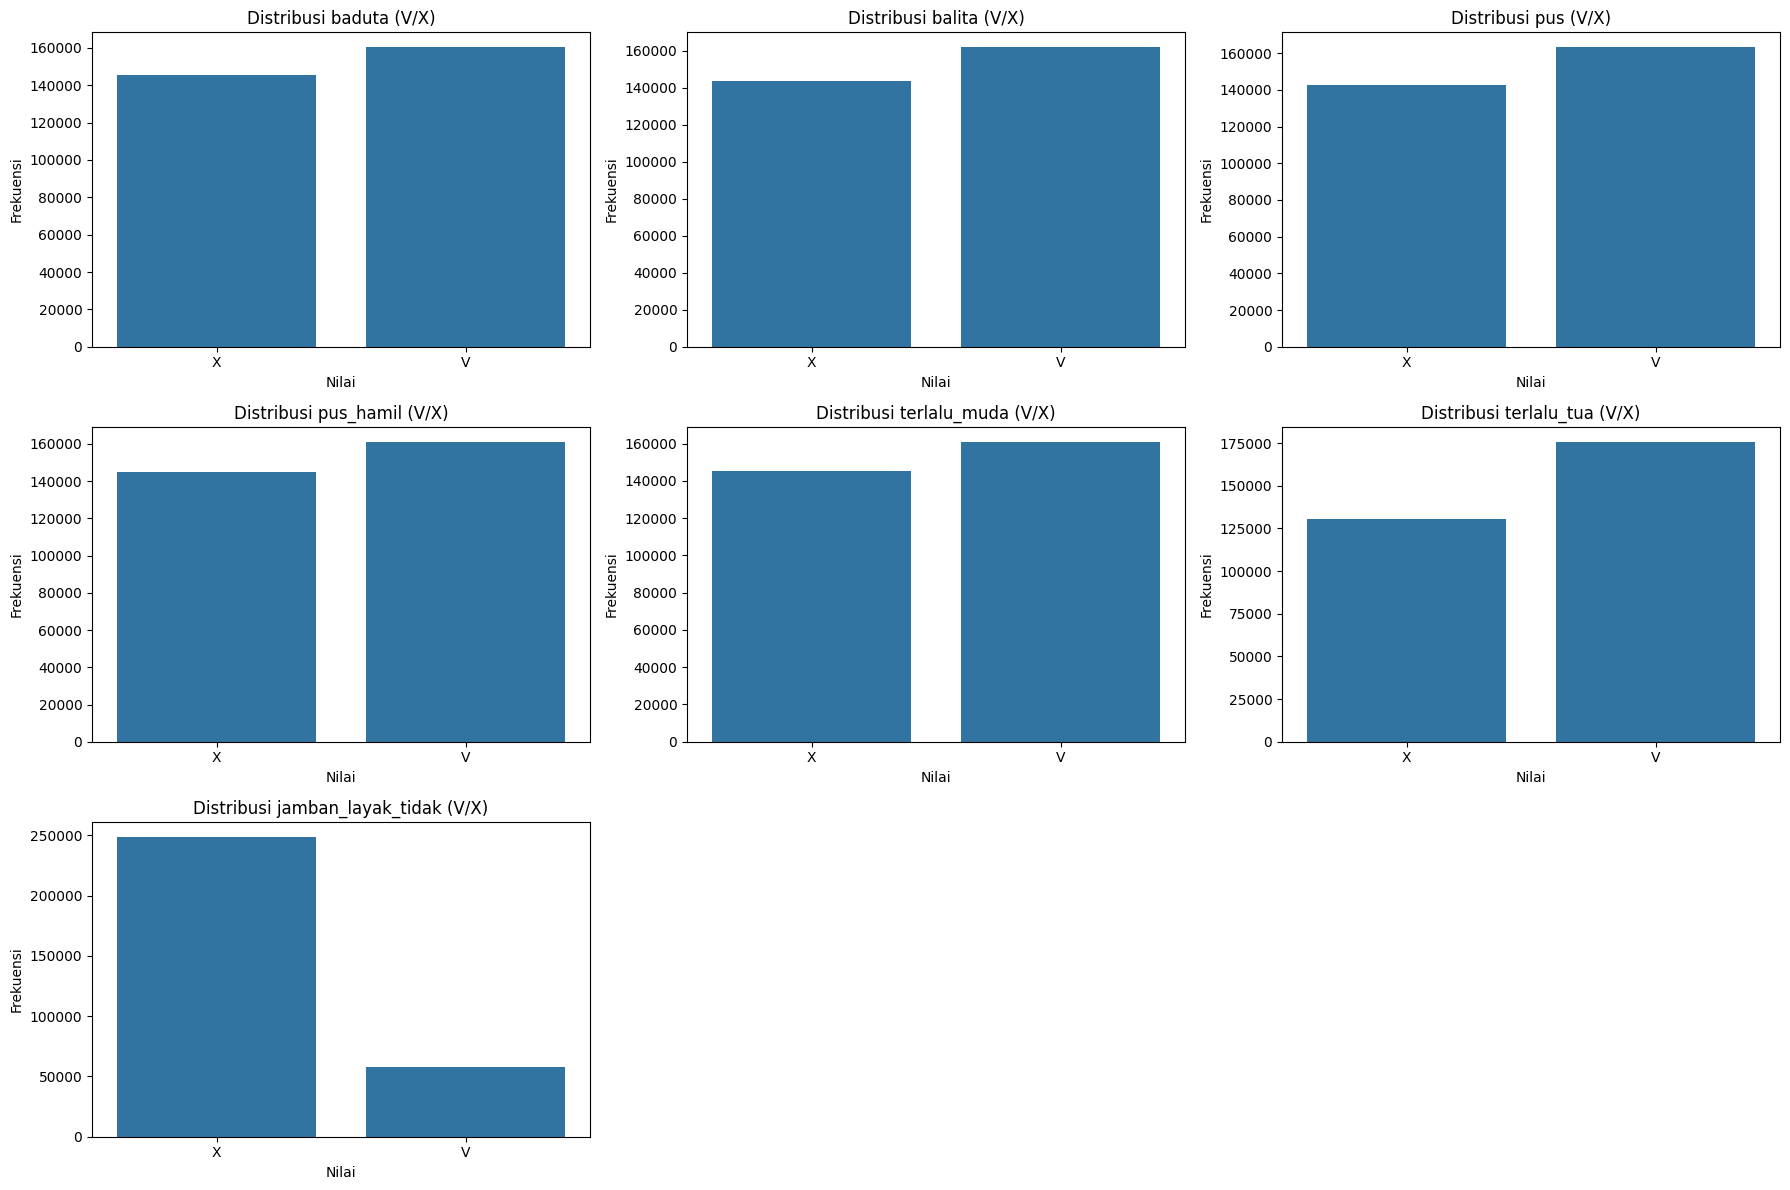

In [5]:
n_cols = 3
binary_cols = [col for col in fitur if df_eda[col].dtype == object]
n_rows = (len(binary_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    if col in df_eda.columns:
        sns.countplot(x=col, data=df_eda, ax=axes[i], order=['X','V'])
        axes[i].set_title(f'Distribusi {col} (V/X)')
        axes[i].set_xlabel('Nilai')
        axes[i].set_ylabel('Frekuensi')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


C:\Users\DK\AppData\Local\Temp\ipykernel_19400\4146886117.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_corr = df_corr.replace({'X':0,'V':1,'x':0,'v':1,'VV':1})


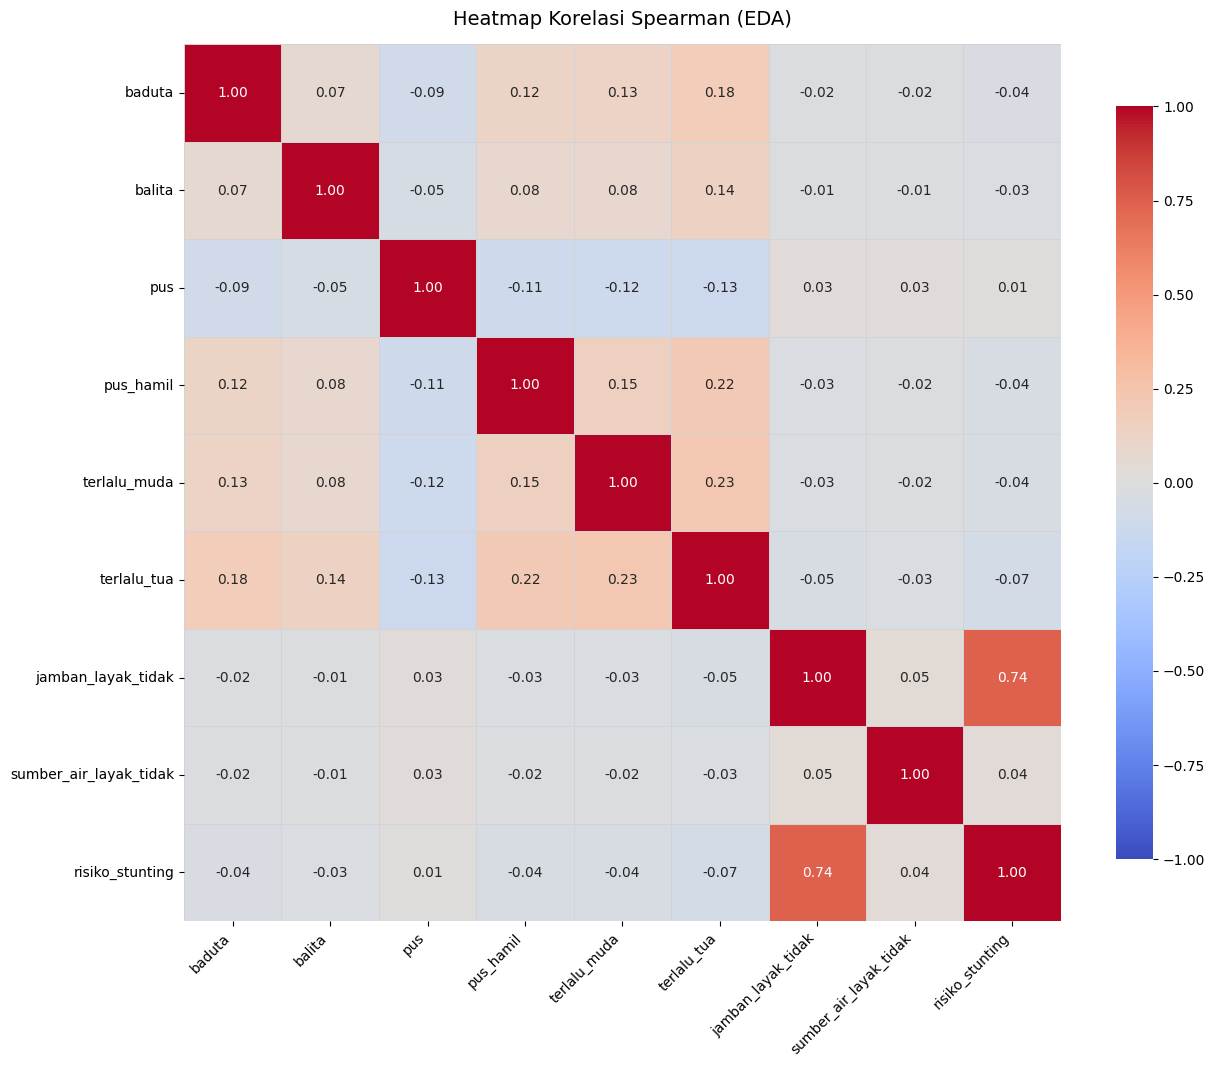

In [6]:
target_cols = fitur.copy()
y_col = "risiko_stunting"
df_corr = df_eda[target_cols + [y_col]].copy()
df_corr = df_corr.replace({'X':0,'V':1,'x':0,'v':1,'VV':1})
for col in target_cols + [y_col]:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')
df_corr = df_corr.dropna(subset=target_cols + [y_col])

corr_matrix = df_corr[target_cols + [y_col]].corr(method='spearman')

plt.figure(figsize=(13,11))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor='lightgray',
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Spearman (EDA)', fontsize=14, pad=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

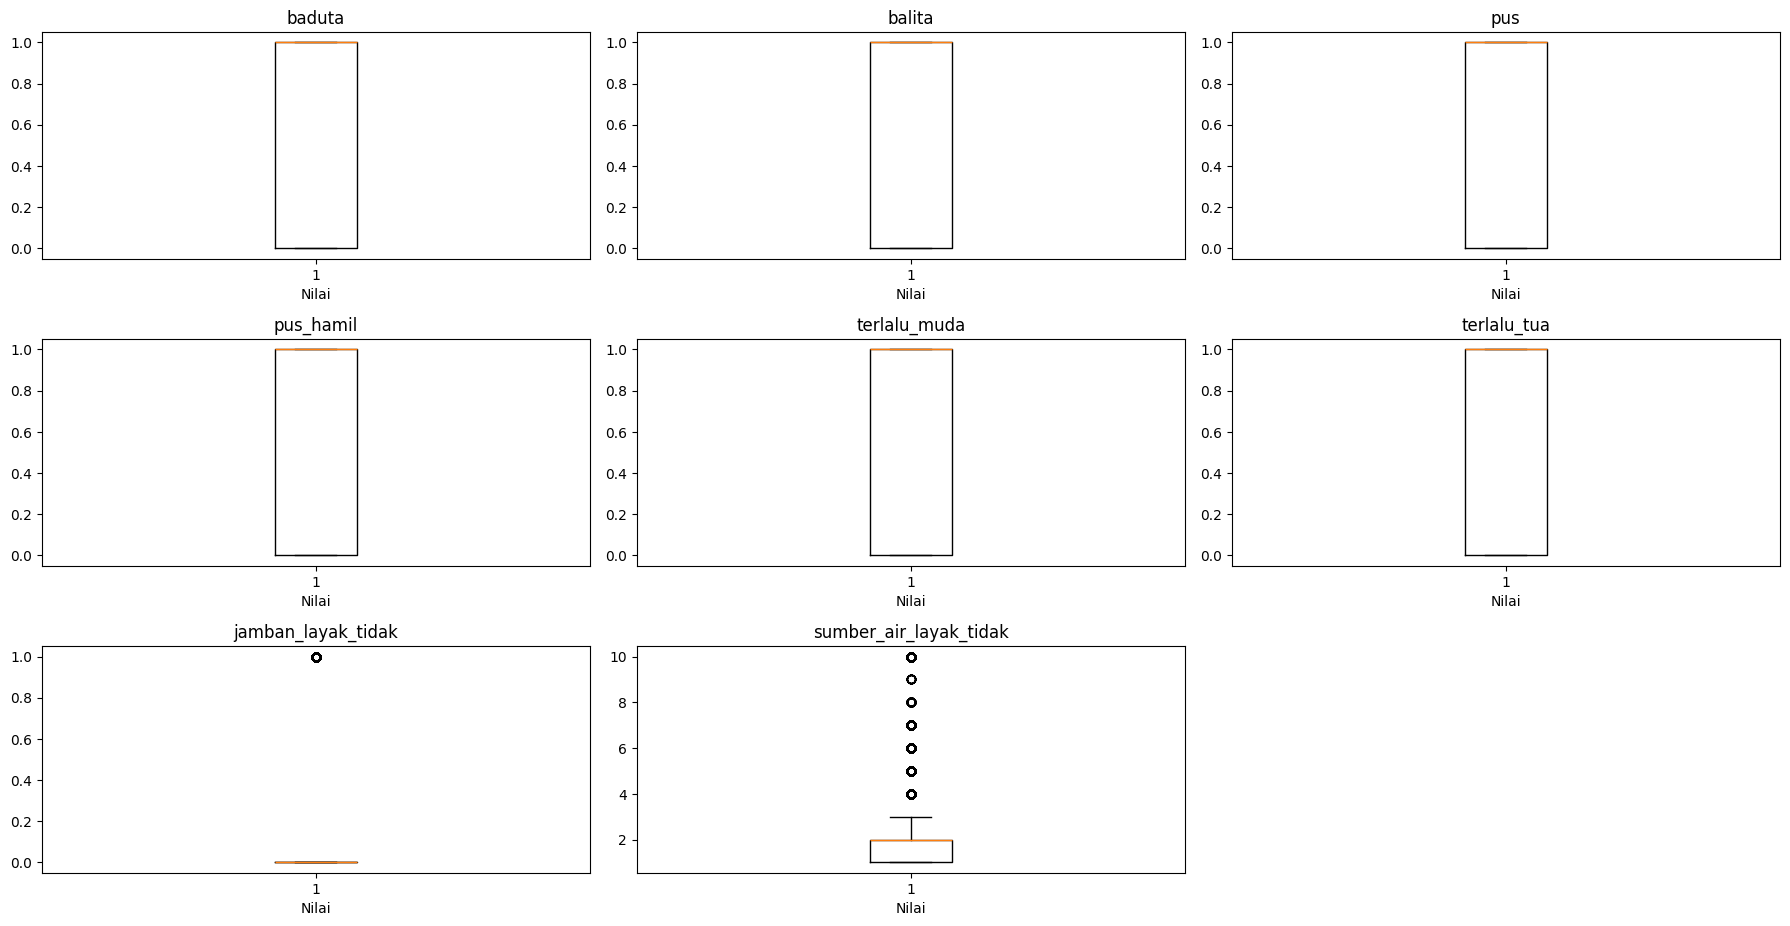

In [7]:
plt.figure(figsize=(18,12))
for i, col in enumerate(target_cols, 1):
    plt.subplot(4, 3, i)
    plt.boxplot(df_corr[col].dropna())
    plt.title(f'{col}')
    plt.xlabel('Nilai')
plt.tight_layout()
plt.show()

In [8]:
df_iqr_vis = df_corr.copy()
for col in target_cols:
    Q1 = df_iqr_vis[col].quantile(0.25)
    Q3 = df_iqr_vis[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_iqr_vis[col] = df_iqr_vis[col].clip(lower, upper)

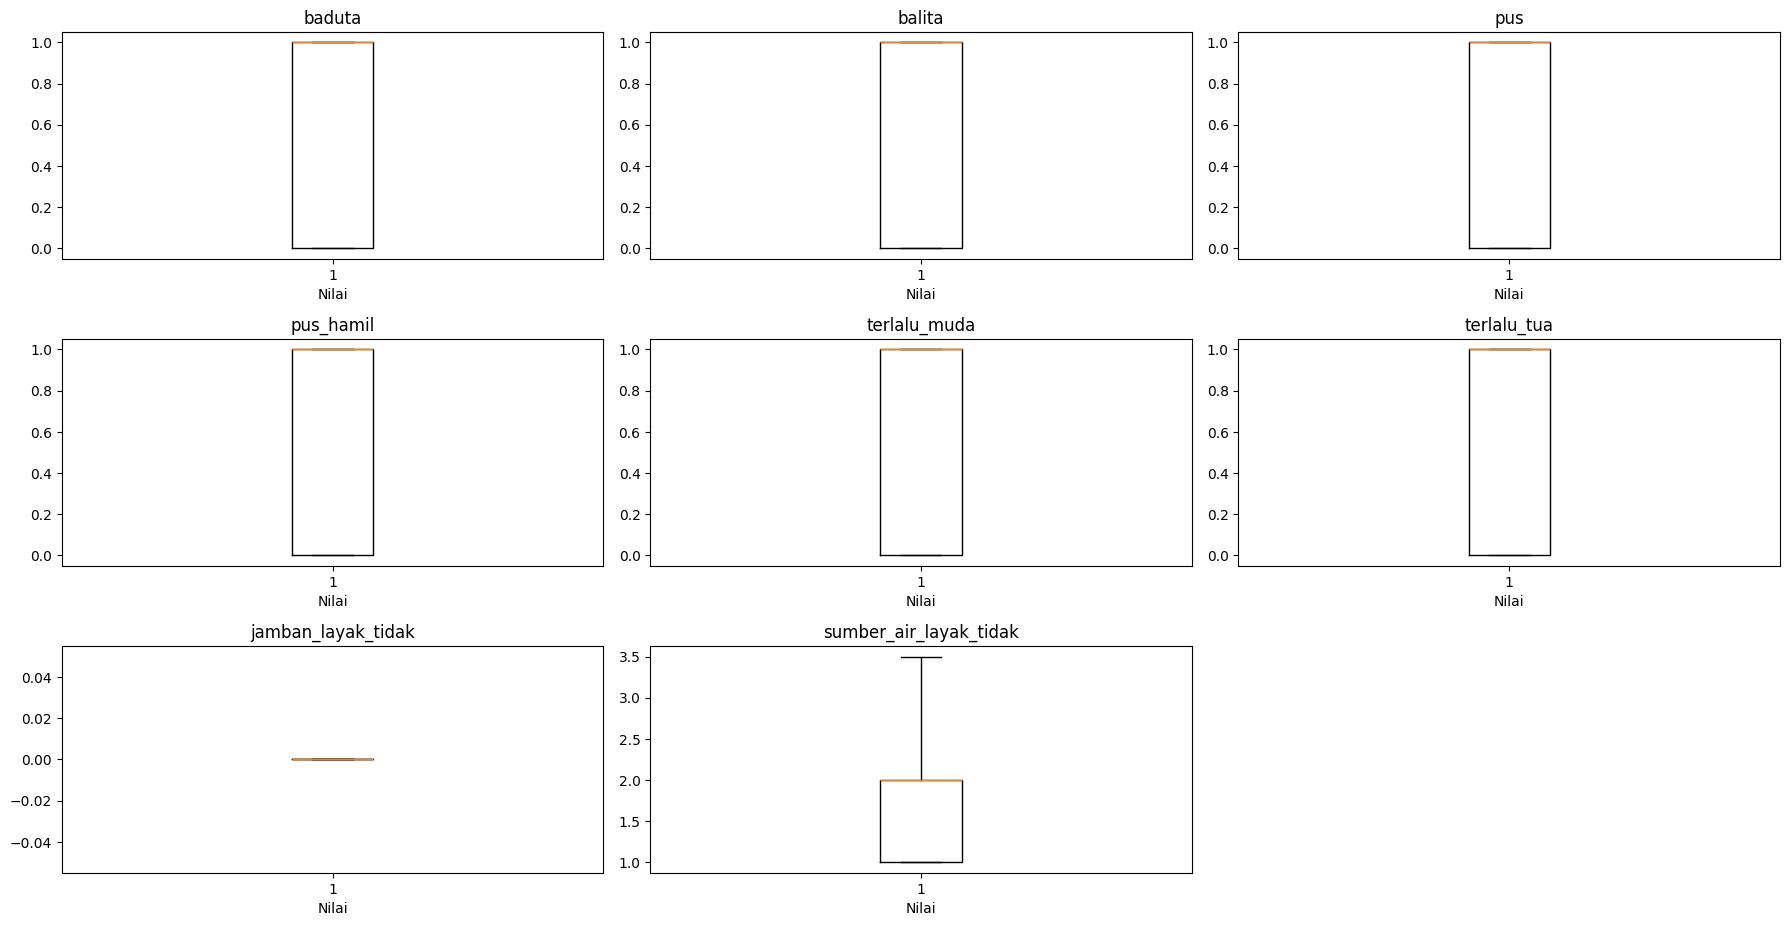

In [9]:
plt.figure(figsize=(18,12))
for i, col in enumerate(target_cols, 1):
    plt.subplot(4, 3, i)
    plt.boxplot(df_iqr_vis[col].dropna())
    plt.title(f'{col}')
    plt.xlabel('Nilai')
plt.tight_layout()
plt.show()

In [10]:
df_clean = df.copy()

df_clean = df_clean.drop(
    columns=['namakecamatan', 'namakelurahan', 'Tahun', 'lat', 'lon'],
    errors='ignore'
)

In [11]:
X = df_clean[target_cols].copy()
y = df_clean[y_col].copy()

In [12]:
X = X.replace({'X': 0, 'V': 1})
X = X.apply(pd.to_numeric, errors='coerce')
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
mask_outlier = ~((X < (Q1 - 1.5*IQR)) | (X > (Q3 + 1.5*IQR))).any(axis=1)

X = X.loc[mask_outlier].copy()
y = y.loc[mask_outlier].copy()

C:\Users\DK\AppData\Local\Temp\ipykernel_19400\210087291.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.replace({'X': 0, 'V': 1})


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
model_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric=['logloss', 'error'],
    use_label_encoder=False,
    random_state=42,
    learning_rate=0.1,
    subsample=0.8,
    early_stopping_rounds=10,
    scale_pos_weight=6  
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=True
)

print("Training selesai!\n")

[0]	validation_0-logloss:0.64081	validation_0-error:0.13210	validation_1-logloss:0.64119	validation_1-error:0.13364
[1]	validation_0-logloss:0.63423	validation_0-error:0.18950	validation_1-logloss:0.63483	validation_1-error:0.19241
[2]	validation_0-logloss:0.62895	validation_0-error:0.21325	validation_1-logloss:0.62978	validation_1-error:0.21704
[3]	validation_0-logloss:0.62445	validation_0-error:0.21824	validation_1-logloss:0.62548	validation_1-error:0.22280
[4]	validation_0-logloss:0.62061	validation_0-error:0.22932	validation_1-logloss:0.62181	validation_1-error:0.23240
[5]	validation_0-logloss:0.61780	validation_0-error:0.24523	validation_1-logloss:0.61918	validation_1-error:0.24866
[6]	validation_0-logloss:0.61537	validation_0-error:0.25162	validation_1-logloss:0.61691	validation_1-error:0.25502
[7]	validation_0-logloss:0.61336	validation_0-error:0.25450	validation_1-logloss:0.61503	validation_1-error:0.25839
[8]	validation_0-logloss:0.61145	validation_0-error:0.25478	validation_1

c:\Users\DK\OneDrive\stunting\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [08:33:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[10]	validation_0-logloss:0.60878	validation_0-error:0.25853	validation_1-logloss:0.61079	validation_1-error:0.26216
Training selesai!



In [31]:
# 5. Evaluasi Model
y_pred = model_xgb.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"Akurasi Model: {akurasi * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Akurasi Model: 86.64%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93     34648
           1       0.35      0.04      0.08      5137

    accuracy                           0.87     39785
   macro avg       0.61      0.52      0.50     39785
weighted avg       0.81      0.87      0.82     39785



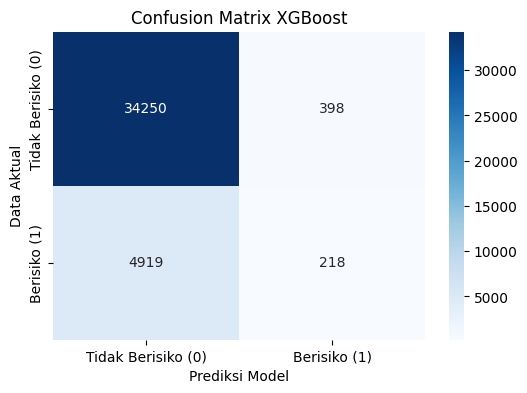

In [32]:
# ==========================================
# VISUALISASI CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tidak Berisiko (0)', 'Berisiko (1)'], 
            yticklabels=['Tidak Berisiko (0)', 'Berisiko (1)'])
plt.title('Confusion Matrix XGBoost')
plt.xlabel('Prediksi Model')
plt.ylabel('Data Aktual')
plt.show()


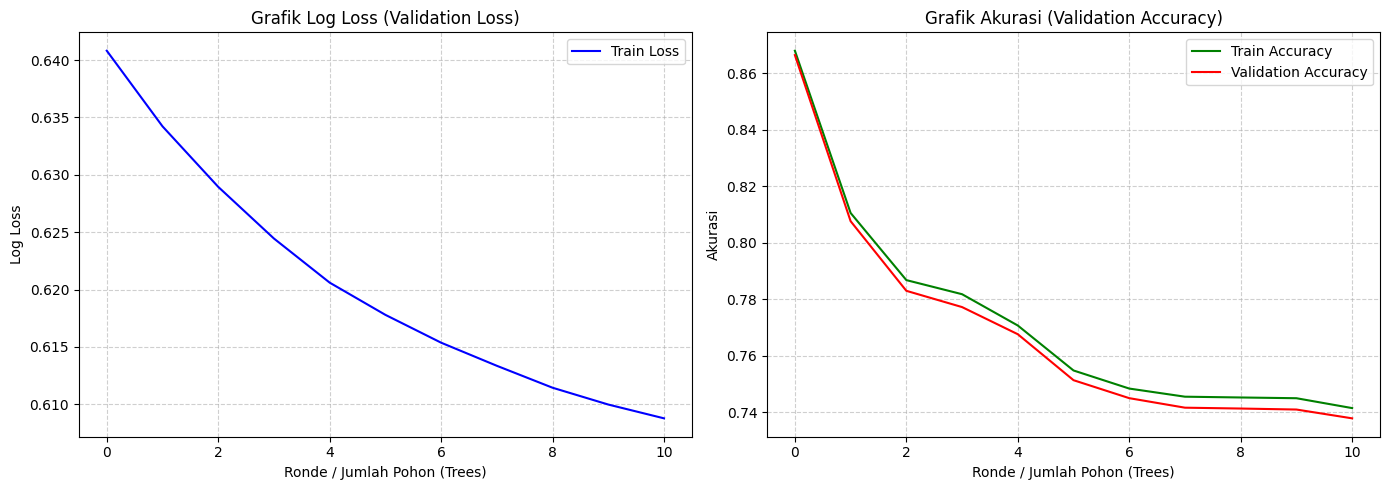

In [34]:
import matplotlib.pyplot as plt

# ==========================================
# VISUALISASI LOGLOSS & ACCURACY
# ==========================================
# Mengambil riwayat hasil evaluasi dari memori model
results = model_xgb.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------
# Grafik 1: Log Loss (Validation Loss)
# ------------------------------------
# Idealnya garis harus sama-sama TURUN
ax[0].plot(x_axis, results['validation_0']['logloss'], label='Train Loss', color='blue')
eval_set=[(X_test, y_test)]  # Only one dataset
ax[0].legend()
ax[0].set_title('Grafik Log Loss (Validation Loss)')
ax[0].set_xlabel('Ronde / Jumlah Pohon (Trees)')
ax[0].set_ylabel('Log Loss')
ax[0].grid(True, linestyle='--', alpha=0.6)


# ------------------------------------
# Grafik 2: Accuracy (Validation Accuracy)
# ------------------------------------
# Konversi dari metrik 'error' bawaan XGBoost menjadi 'accuracy'
train_accuracy = [1 - e for e in results['validation_0']['error']]

ax[1].plot(x_axis, train_accuracy, label='Train Accuracy', color='green')
val_accuracy = [1 - e for e in results['validation_1']['error']]
ax[1].plot(x_axis, val_accuracy, label='Validation Accuracy', color='red')
ax[1].legend()
ax[1].set_title('Grafik Akurasi (Validation Accuracy)')
ax[1].set_xlabel('Ronde / Jumlah Pohon (Trees)')
ax[1].set_ylabel('Akurasi')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# 1) simpan raw test hasil inverse transform (SUDAH BENAR)
from xml.parsers.expat import model


X_test_raw = scaler.inverse_transform(X_test)

with open("data_test_xgboost.pkl", "wb") as f:
    pickle.dump((X_test_raw, y_test), f)

# 2) simpan scaler
with open("scaler_xgboost.pkl", "wb") as f:
    pickle.dump(scaler, f)

# 3) simpan model
# 3) simpan model
model_xgb.save_model("model_xgboost.model")

# 4) simpan history
with open("history_xgboost.pkl", "wb") as f:
    # 1) simpan raw test hasil inverse transform (SUDAH BENAR)


    X_test_raw = scaler.inverse_transform(X_test)

    with open("data_test_xgboost.pkl", "wb") as f:
        pickle.dump((X_test_raw, y_test), f)

    # 2) simpan scaler
    with open("scaler_xgboost.pkl", "wb") as f:
        pickle.dump(scaler, f)

    # 3) simpan model
    model_xgb.save_model("model_xgboost.model")

    # 4) simpan history
    with open("history_xgboost.pkl", "wb") as f:
        pickle.dump(model_xgb.evals_result(), f)

    print("✅ Semua file xgboost berhasil disimpan FINAL")

print("✅ Semua file xgboost berhasil disimpan FINAL")

c:\Users\DK\OneDrive\stunting\.venv\Lib\site-packages\xgboost\sklearn.py:1122: UserWarning: [08:52:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1564: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


NameError: name 'history' is not defined